# **Deep Learning Lab: Transfer Learning**

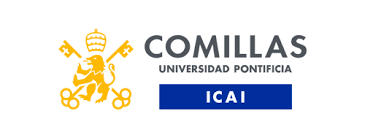

***

In [ ]:
import tensorflow as tf

# Check GPU availability
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Check TPU availability
tpu_available = False
devices = tf.config.list_logical_devices()
for device in devices:
    if device.device_type == 'TPU':
        tpu_available = True
        break

print("TPU Available:", tpu_available)

GPU Available: []
TPU Available: False


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Navigate to code directory
%cd /content/drive/My Drive/dataset

# List project directory contents
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/dataset
cnn.py	__pycache__  training  validation  wandb


## Import packages

In [4]:
from importlib import reload  # Allows reloading user libraries
import sys
#sys.path.append('/content/drive/My Drive/dataset')
import cnn
from cnn import CNN
import torchvision
from cnn import load_data
from cnn import load_model_weights
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import os
import json

## Model and data loading

In [5]:
# Pytorch has many pre-trained models that can be used for transfer learning
classification_models = torchvision.models.list_models(module=torchvision.models)
print(classification_models)

['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'densenet121', 'densenet161', 'densenet169', 'densenet201', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_v2_l', 'efficientnet_v2_m', 'efficientnet_v2_s', 'googlenet', 'inception_v3', 'maxvit_t', 'mnasnet0_5', 'mnasnet0_75', 'mnasnet1_0', 'mnasnet1_3', 'mobilenet_v2', 'mobilenet_v3_large', 'mobilenet_v3_small', 'regnet_x_16gf', 'regnet_x_1_6gf', 'regnet_x_32gf', 'regnet_x_3_2gf', 'regnet_x_400mf', 'regnet_x_800mf', 'regnet_x_8gf', 'regnet_y_128gf', 'regnet_y_16gf', 'regnet_y_1_6gf', 'regnet_y_32gf', 'regnet_y_3_2gf', 'regnet_y_400mf', 'regnet_y_800mf', 'regnet_y_8gf', 'resnet101', 'resnet152', 'resnet18', 'resnet34', 'resnet50', 'resnext101_32x8d', 'resnext101_64x4d', 'resnext50_32x4d', 'shufflenet_v2_x0_5', 'shufflenet_v2_x1_0', 'shufflenet_v2_x1_5', 'shufflenet_v2_x2_0', 'squeezenet1_0

In [6]:
# Load data and model
train_dir = 'dataset/training'
valid_dir = 'dataset/validation'




train_loader, valid_loader, num_classes = load_data(train_dir,
                                                    valid_dir,
                                                    batch_size=128,
                                                    img_size=224) # ResNet50 requires 224x224 images

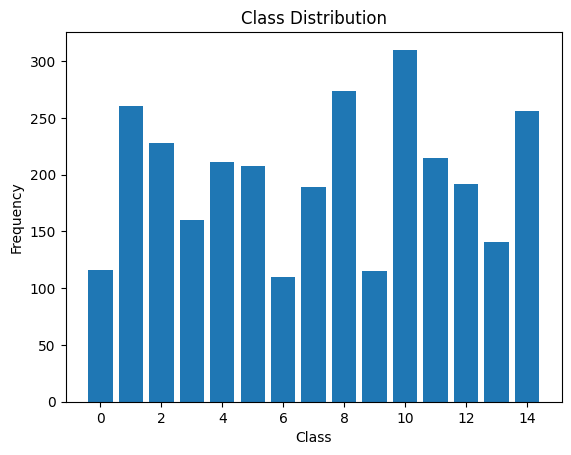

In [ ]:
## CUIDADO, TARDA 14 MINUTOS
# veo la distribución de las clases
class_distribution = np.zeros(num_classes)
for _, labels in train_loader:
    for label in labels:
        class_distribution[label] += 1

plt.bar(range(num_classes), class_distribution)
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Class Distribution')
plt.show()

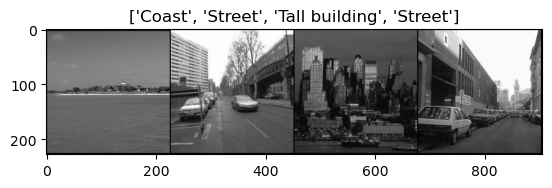

In [15]:
# Visualize a few images
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a few random images
random_indices = np.random.choice(len(valid_loader.dataset), size=4, replace=False)
inputs = []
classes = []
for i in random_indices:
    inputs.append(valid_loader.dataset[i][0])
    classes.append(valid_loader.dataset[i][1])
out = torchvision.utils.make_grid(inputs)
classnames = train_loader.dataset.classes
imshow(out, title=[classnames[x] for x in classes])

Comprobacion de que se está usando GPU

## Train

In [55]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Usando GPU MPS")
else:
    device = torch.device("cpu")
    print("Usando CPU")

Usando GPU MPS


In [37]:
import torchvision
from cnn import CNN

# Instanciamos sin preocuparnos de pesos
bm = torchvision.models.efficientnet_b0(weights=None)
print(list(bm.children()))

[Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (1): Sequential(
    (0): MBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (activation): SiLU(inplace=True)
          (scale_activation): Sigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1),

In [49]:
# Inspección rápida de varios parámetros
for name, param in model.named_parameters():
    if any(x in name for x in ["features.7", "features.8", "fc", "classifier"]):
        print(f"{name:60s} -> requires_grad={param.requires_grad}")
    # Si quieres ver los que quedan congelados descomenta:
    else:
         print(f"{name:60s} -> frozen")

base_model.features.0.0.weight                               -> frozen
base_model.features.0.1.weight                               -> frozen
base_model.features.0.1.bias                                 -> frozen
base_model.features.1.0.block.0.0.weight                     -> frozen
base_model.features.1.0.block.0.1.weight                     -> frozen
base_model.features.1.0.block.0.1.bias                       -> frozen
base_model.features.1.0.block.1.fc1.weight                   -> requires_grad=True
base_model.features.1.0.block.1.fc1.bias                     -> requires_grad=True
base_model.features.1.0.block.1.fc2.weight                   -> requires_grad=True
base_model.features.1.0.block.1.fc2.bias                     -> requires_grad=True
base_model.features.1.0.block.2.0.weight                     -> frozen
base_model.features.1.0.block.2.1.weight                     -> frozen
base_model.features.1.0.block.2.1.bias                       -> frozen
base_model.features.2.0.block

In [75]:
#device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

# 1) Instancia el EfficientNet‑B0 pre‑entrenado
base = torchvision.models.efficientnet_b0(weights='DEFAULT')

# 2) Guarda la capa Linear original (para leer sus in_features)
orig_linear = base.classifier[1]   # es nn.Linear(1280, 1000)

# 3) “Neutraliza” el classifier para que devuelva el embedding de 1280
base.classifier = torch.nn.Identity()

# 4) Pon un alias `.fc` para que tu wrapper vea base_model.fc.in_features
base.fc = orig_linear

# 5) Crea tu modelo con 1 capa descongelada (la cabeza) y luego parchea manualmente MBConv7+8
model = CNN(base, num_classes, unfreezed_layers=3).to(device)


#for p in model.base_model.features[8].parameters():
#    p.requires_grad = True

# 4) Verifica que sólo esos y tu cabeza están verdaderamente descongelados
for name, p in model.named_parameters():
    print(f"{name:60s} -> requires_grad={p.requires_grad}")


base_model.features.0.0.weight                               -> requires_grad=False
base_model.features.0.1.weight                               -> requires_grad=False
base_model.features.0.1.bias                                 -> requires_grad=False
base_model.features.1.0.block.0.0.weight                     -> requires_grad=False
base_model.features.1.0.block.0.1.weight                     -> requires_grad=False
base_model.features.1.0.block.0.1.bias                       -> requires_grad=False
base_model.features.1.0.block.1.fc1.weight                   -> requires_grad=False
base_model.features.1.0.block.1.fc1.bias                     -> requires_grad=False
base_model.features.1.0.block.1.fc2.weight                   -> requires_grad=False
base_model.features.1.0.block.1.fc2.bias                     -> requires_grad=False
base_model.features.1.0.block.2.0.weight                     -> requires_grad=False
base_model.features.1.0.block.2.1.weight                     -> requires_gra

In [76]:
model.parameters()

<generator object Module.parameters at 0x137e5ece0>

In [77]:
# 7) Ahora ya puedes entrenar sin choques de dimensiones:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    'min', 
    patience=3, 
    factor=0.1) # Reduce learning rate on plateau, i.e., when the validation loss stops decreasing

criterion = torch.nn.CrossEntropyLoss()

history = model.train_model(
    train_loader,
    valid_loader,
    optimizer,
    criterion,
    epochs=30,
    scheduler=scheduler,
    patience=6
)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 1/30 - Train Loss: 2.6946, Train Accuracy: 0.0965
Epoch 1/30 - Validation Loss: 2.7044, Validation Accuracy: 0.0733
Epoch 2/30 - Train Loss: 2.6912, Train Accuracy: 0.0968
Epoch 2/30 - Validation Loss: 2.7017, Validation Accuracy: 0.0753
Epoch 3/30 - Train Loss: 2.6901, Train Accuracy: 0.1018
Epoch 3/30 - Validation Loss: 2.7009, Validation Accuracy: 0.0933
Epoch 4/30 - Train Loss: 2.6891, Train Accuracy: 0.0978
Epoch 4/30 - Validation Loss: 2.7016, Validation Accuracy: 0.0847
Epoch 5/30 - Train Loss: 2.6884, Train Accuracy: 0.0988
Epoch 5/30 - Validation Loss: 2.7033, Validation Accuracy: 0.0960
Epoch 6/30 - Train Loss: 2.6889, Train Accuracy: 0.0972
Epoch 6/30 - Validation Loss: 2.7018, Validation Accuracy: 0.0900
Epoch 7/30 - Train Loss: 2.6879, Train Accuracy: 0.1045
Epoch 7/30 - Validation Loss: 2.7034, Validation Accuracy: 0.0953
Epoch 8/30 - Train Loss: 2.6855, Train Accuracy: 0.1069
Epoch 8/30 - Validation Loss: 2.7011, Validation Accuracy: 0.0847
Epoch 9/30 - Train Loss:

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 20/30 - Validation Loss: 2.7003, Validation Accuracy: 0.1167
Early stopping triggered.


learning_rate,██████▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▁▄▂▂▁▆▇▆█▅▇▆█▆▇█▆▅▇
train_loss,█▆▅▄▄▄▄▂▂▂▂▁▂▂▂▂▁▁▂▁
validation_accuracy,▁▁▃▂▄▃▄▂▆▅▄▄▄█▄▅▆▅▄▆
validation_loss,█▅▄▅▇▅▇▄▄▃▄▄▄▂▄▆▁▃▆▃
learning_rate,1e-05
train_accuracy,0.1072
train_loss,2.68429
validation_accuracy,0.11667
validation_loss,2.70027


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,'min', patience=3, factor=0.1) # Reduce learning rate on plateau, i.e., when the validation loss stops decreasing
criterion = nn.CrossEntropyLoss()
history = model.train_model(train_loader, valid_loader, optimizer, criterion, epochs=30, scheduler=scheduler, patience=6)

In [11]:
model.save_model('efficient_net_b0')

## Predict

#### Load model

In [12]:
# Load model
model_weights = load_model_weights('efficient_net_b0')
my_trained_model = CNN(torchvision.models.resnet50(weights='DEFAULT'), num_classes)
my_trained_model.load_state_dict(model_weights)

<All keys matched successfully>

## Results

In [13]:
predicted_labels = my_trained_model.predict(valid_loader)

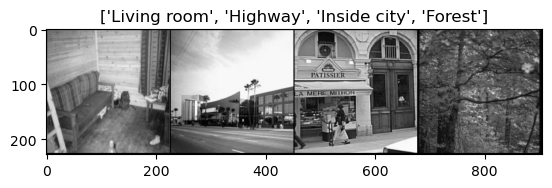

In [16]:
# Get a few random images
random_indices = np.random.choice(len(valid_loader.dataset), size=4, replace=False)
inputs = []
classes = []
for i in random_indices:
    inputs.append(valid_loader.dataset[i][0])
    classes.append(predicted_labels[i])

out = torchvision.utils.make_grid(inputs)
classnames = train_loader.dataset.classes
imshow(out, title=[classnames[x] for x in classes])


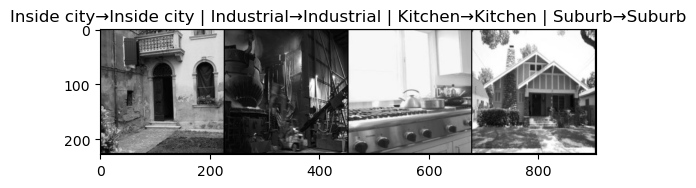

In [19]:
# Selección de índices aleatorios
random_indices = np.random.choice(len(valid_loader.dataset), size=4, replace=False)

# Preparamos las entradas, las predicciones y las verdaderas
inputs, preds, trues = [], [], []
for i in random_indices:
    img, true = valid_loader.dataset[i]
    inputs.append(img)
    preds.append(predicted_labels[i])
    trues.append(true)

# Creamos el grid
out = torchvision.utils.make_grid(inputs)

# Generamos un título global que liste True vs Pred para cada subimagen
classnames = train_loader.dataset.classes
labels = [f"{classnames[t]}→{classnames[p]}" for t, p in zip(trues, preds)]
title = " | ".join(labels)

# Mostramos
imshow(out, title=title)

In [24]:
from PIL import Image
import torch
import torchvision
from cnn import load_data, CNN

# 1) Carga el valid_loader para extraer el transform
train_loader, valid_loader, num_classes = load_data(
    train_dir='dataset/training',
    valid_dir='dataset/validation',
    batch_size=128,
    img_size=224
)
infer_transform = valid_loader.dataset.transform
class_names    = valid_loader.dataset.classes

# 2) Detecta dispositivo en Mac (MPS) o CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Usando GPU MPS")
else:
    device = torch.device("cpu")
    print("Usando CPU")

# 3) Función de predicción
def predict_image(path, model, class_names, device):
    img = Image.open(path).convert('RGB')
    x   = infer_transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        pred   = logits.argmax(dim=1).item()
    return class_names[pred]

# 4) Instancia el modelo igual que en entrenamiento (3 capas descongeladas)
model = CNN(torchvision.models.resnet50(weights=None),
            num_classes,
            unfreezed_layers=3)
# 5) Carga pesos y pasa a device
model.load_state_dict(torch.load(
    'models/resnet50_3_unfreeze_layer.pt',
    map_location=device
))
model.to(device)

# 6) Predice tu imagen
ruta = 'dataset/validation/Open country/image_0074.jpg'
pred = predict_image(ruta, model, class_names, device)
print(f"Predicción: {pred}")

Usando GPU MPS
Predicción: Open country


In [30]:
from PIL import Image
import torch
import torchvision.transforms as T
import torchvision
from cnn import CNN

# Nuevo transform para inferencia
infer_transform = T.Compose([
    T.Grayscale(num_output_channels=3),   # ← aquí convertimos a escala de grises (3×idéntico)
    T.Resize((224, 224)),
    T.ToTensor(),
])

class_names = [ 'Bedroom','Office','Coast','Forest','Highway',
                'Industrial','Inside city','Kichen','Living room',
                'Mountain','Open country','Store','Street','Suburb',
                'Tall building' ]

# Detecta MPS o CPU
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

# Instancia y carga el modelo (igual que antes)
model = CNN(torchvision.models.resnet50(weights=None),
            num_classes=len(class_names),
            unfreezed_layers=3)
model.load_state_dict(torch.load('models/resnet50_3_unfreeze_layer.pt',
                                 map_location=device))
model.to(device).eval()

def predict_one(path):
    img = Image.open(path).convert('RGB')
    x   = infer_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        idx = model(x).argmax(1).item()
    return class_names[idx]

# Ejemplo:
print(predict_one('test/Living room.jpg'))

Kichen


In [35]:
from PIL import Image
import torch
import torchvision.transforms as T
import torchvision
from torchvision.datasets import ImageFolder
from cnn import CNN

# 1) Transform para inferencia (gris → 3 canales)
infer_transform = T.Compose([
    T.Grayscale(num_output_channels=3),
    T.Resize((224, 224)),
    T.ToTensor(),
])

# 2) Carga automática de las clases desde tus datos de validación
dataset = ImageFolder(root='dataset/validation')  # pon aquí la ruta a tu carpeta de validation
class_names = dataset.classes

# 3) Dispositivo (MPS en Mac o CPU)
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

# 4) Instancia tu modelo (igual que en entrenamiento)
model = CNN(torchvision.models.resnet50(weights=None),
            num_classes=len(class_names),
            unfreezed_layers=3)

# 5) Carga los pesos ya entrenados
model.load_state_dict(torch.load(
    'models/resnet50_3_unfreeze_layer.pt',
    map_location=device
))
model.to(device).eval()

# 6) Función mínima para predecir una imagen suelta
def predict_one(path):
    img = Image.open(path).convert('RGB')
    x   = infer_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        pred_idx = model(x).argmax(1).item()
    return class_names[pred_idx]

# 7) Ejemplo de uso
print(predict_one('test/Living room.jpg'))

Living room


In [36]:
from cnn import load_data

train_dir = 'dataset/training'
valid_dir = 'dataset/validation'

train_loader, valid_loader, num_classes = load_data(
    train_dir, valid_dir,
    batch_size=1,    # da igual el batch size, solo queremos contar
    img_size=224
)

print(f"Número de imágenes de train: {len(train_loader.dataset)}")
print(f"Número de imágenes de valid: {len(valid_loader.dataset)}")
print(f"Total imágenes: {len(train_loader.dataset) + len(valid_loader.dataset)}")

Número de imágenes de train: 2985
Número de imágenes de valid: 1500
Total imágenes: 4485
